# 7. Modelowanie predykcyjne

W tej części pracy przeprowadzono budowę oraz porównanie modeli predykcyjnych służących do estymacji ceny ofertowej nieruchomości. Analizie poddano zarówno klasyczne modele regresyjne, jak i modele typu ensemble. Dodatkowo oceniono wpływ danych tekstowych na jakość predykcji.

## 7.1. Regresja liniowa

W pierwszym etapie modelowania zastosowano regresję liniową jako model bazowy służący do oceny wpływu cech numerycznych oraz danych tekstowych na jakość predykcji ceny nieruchomości.

In [13]:
# ============================================================
# Import bibliotek
# ============================================================

import pandas as pd
import numpy as np

from scipy.sparse import load_npz, hstack

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [23]:
# ============================================================
# Wczytanie zapisanych obiektów
# ============================================================

import joblib

tfidf_vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

In [2]:
# ============================================================
# Wczytanie przygotowanych danych
# ============================================================

df_model = pd.read_csv("df_model.csv")
X_text_tfidf = load_npz("X_text_tfidf.npz")

print("df_model:", df_model.shape)
print("X_text_tfidf:", X_text_tfidf.shape)

df_model: (7934, 14)
X_text_tfidf: (7934, 1000)


In [3]:
# ============================================================
# Przygotowanie zbiorów cech
# ============================================================

numeric_features = [
    "log_sqft",
    "beds",
    "baths"
]

X_numeric = df_model[numeric_features].fillna(0)

X_full = hstack([
    X_numeric.values,
    X_text_tfidf
])

y = df_model["log_listPrice"]

print("X_numeric:", X_numeric.shape)
print("X_full:", X_full.shape)
print("y:", y.shape)

X_numeric: (7934, 3)
X_full: (7934, 1003)
y: (7934,)


In [4]:
# ============================================================
# Podział danych na zbiór treningowy i testowy
# ============================================================

X_num_train, X_num_test, X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_numeric,
    X_full,
    y,
    test_size=0.2,
    random_state=42
)

print("X_num_train:", X_num_train.shape)
print("X_num_test:", X_num_test.shape)

print("X_full_train:", X_full_train.shape)
print("X_full_test:", X_full_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_num_train: (6347, 3)
X_num_test: (1587, 3)
X_full_train: (6347, 1003)
X_full_test: (1587, 1003)
y_train: (6347,)
y_test: (1587,)


In [5]:
# ============================================================
# Funkcja oceny modelu
# ============================================================

def evaluate_model(model_name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2_log": r2_score(y_true_log, y_pred_log)
    }

In [6]:
# ============================================================
# Model 1: Regresja liniowa na cechach numerycznych
# ============================================================

linear_numeric = LinearRegression()

linear_numeric.fit(
    X_num_train,
    y_train
)

y_pred_numeric = linear_numeric.predict(
    X_num_test
)

results = []

results.append(
    evaluate_model(
        "Linear Regression - cechy numeryczne",
        y_test,
        y_pred_numeric
    )
)

In [7]:
# ============================================================
# Model 2: Regresja liniowa na cechach numerycznych i tekstowych
# ============================================================

linear_full = LinearRegression()

linear_full.fit(
    X_full_train,
    y_train
)

y_pred_full = linear_full.predict(
    X_full_test
)

results.append(
    evaluate_model(
        "Linear Regression - cechy numeryczne + TF-IDF",
        y_test,
        y_pred_full
    )
)

In [8]:
# ============================================================
# Porównanie wyników regresji liniowej
# ============================================================

linear_results = pd.DataFrame(results)

linear_results[["MAE", "RMSE"]] = linear_results[["MAE", "RMSE"]].round(2)
linear_results["R2_log"] = linear_results["R2_log"].round(4)

linear_results

,model,MAE,RMSE,R2_log
0,Linear Regression - cechy numeryczne,986079.01,11495972.49,0.3037
1,Linear Regression - cechy numeryczne + TF-IDF,495655.55,1571498.94,0.6048


## 7.2. Random Forest Regressor

W kolejnym etapie zastosowano model Random Forest Regressor, należący do metod ensemble. Model porównano w dwóch wariantach: z wykorzystaniem wyłącznie cech numerycznych oraz z rozszerzeniem o cechy tekstowe TF-IDF.

In [10]:
# ============================================================
# Model 1: Random Forest na cechach numerycznych
# ============================================================

rf_numeric = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_numeric.fit(
    X_num_train,
    y_train
)

y_pred_rf_numeric = rf_numeric.predict(
    X_num_test
)

results.append(
    evaluate_model(
        "Random Forest - cechy numeryczne",
        y_test,
        y_pred_rf_numeric
    )
)

In [11]:
# ============================================================
# Model 2: Random Forest na cechach numerycznych i tekstowych
# ============================================================

rf_full = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(
    X_full_train,
    y_train
)

y_pred_rf_full = rf_full.predict(
    X_full_test
)

results.append(
    evaluate_model(
        "Random Forest - cechy numeryczne + TF-IDF",
        y_test,
        y_pred_rf_full
    )
)

In [12]:
# ============================================================
# Aktualne porównanie wyników modeli
# ============================================================

model_results = pd.DataFrame(results)

model_results[["MAE", "RMSE"]] = model_results[["MAE", "RMSE"]].round(2)
model_results["R2_log"] = model_results["R2_log"].round(4)

model_results

,model,MAE,RMSE,R2_log
0,Linear Regression - cechy numeryczne,986079.01,11495972.49,0.3037
1,Linear Regression - cechy numeryczne + TF-IDF,495655.55,1571498.94,0.6048
2,Random Forest - cechy numeryczne,704716.29,1802915.20,0.2340
3,Random Forest - cechy numeryczne + TF-IDF,475536.34,1505606.83,0.5985


## 7.3. XGBoost Regressor

W kolejnym etapie analizy zastosowano model XGBoost Regressor, należący do grupy metod boostingowych. Model został przeanalizowany zarówno w wariancie wykorzystującym wyłącznie cechy numeryczne, jak i w wersji rozszerzonej o dane tekstowe TF-IDF.

In [14]:
# ============================================================
# Model 1: XGBoost na cechach numerycznych
# ============================================================

xgb_numeric = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_numeric.fit(
    X_num_train,
    y_train
)

y_pred_xgb_numeric = xgb_numeric.predict(
    X_num_test
)

results.append(
    evaluate_model(
        "XGBoost - cechy numeryczne",
        y_test,
        y_pred_xgb_numeric
    )
)

In [15]:
# ============================================================
# Model 2: XGBoost na cechach numerycznych i tekstowych
# ============================================================

xgb_full = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_full.fit(
    X_full_train,
    y_train
)

y_pred_xgb_full = xgb_full.predict(
    X_full_test
)

results.append(
    evaluate_model(
        "XGBoost - cechy numeryczne + TF-IDF",
        y_test,
        y_pred_xgb_full
    )
)

In [16]:
# ============================================================
# Aktualne porównanie wyników modeli
# ============================================================

model_results = pd.DataFrame(results)

model_results[["MAE", "RMSE"]] = model_results[["MAE", "RMSE"]].round(2)
model_results["R2_log"] = model_results["R2_log"].round(4)

model_results

,model,MAE,RMSE,R2_log
0,Linear Regression - cechy numeryczne,986079.01,11495972.49,0.3037
1,Linear Regression - cechy numeryczne + TF-IDF,495655.55,1571498.94,0.6048
2,Random Forest - cechy numeryczne,704716.29,1802915.20,0.2340
3,Random Forest - cechy numeryczne + TF-IDF,475536.34,1505606.83,0.5985
4,XGBoost - cechy numeryczne,640252.25,1731017.28,0.3794
5,XGBoost - cechy numeryczne + TF-IDF,453392.42,1522285.31,0.6497


## 7.4. Porównanie modeli predykcyjnych

W ostatnim etapie analizy porównano skuteczność wszystkich przygotowanych modeli predykcyjnych. Szczególną uwagę poświęcono ocenie wpływu danych tekstowych TF-IDF na jakość predykcji oraz porównaniu skuteczności klasycznych modeli regresyjnych i modeli typu ensemble.

In [17]:
# ============================================================
# Końcowe porównanie modeli
# ============================================================

final_results = model_results.copy()

final_results = final_results.sort_values(
    by="R2_log",
    ascending=False
).reset_index(drop=True)

final_results.index = final_results.index + 1

final_results

,model,MAE,RMSE,R2_log
1,XGBoost - cechy numeryczne + TF-IDF,453392.42,1522285.31,0.6497
2,Linear Regression - cechy numeryczne + TF-IDF,495655.55,1571498.94,0.6048
3,Random Forest - cechy numeryczne + TF-IDF,475536.34,1505606.83,0.5985
4,XGBoost - cechy numeryczne,640252.25,1731017.28,0.3794
5,Linear Regression - cechy numeryczne,986079.01,11495972.49,0.3037
6,Random Forest - cechy numeryczne,704716.29,1802915.20,0.2340


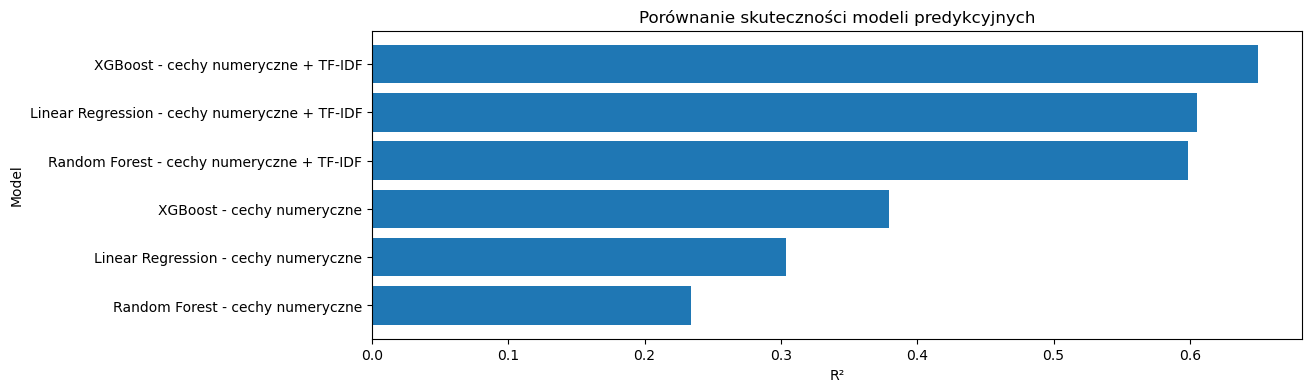

In [21]:
# ============================================================
# Horizontal comparison of model R² scores
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.barh(
    final_results["model"],
    final_results["R2_log"]
)

plt.xlabel("R²")
plt.ylabel("Model")
plt.title("Porównanie skuteczności modeli predykcyjnych")

plt.gca().invert_yaxis()

plt.show()

## 7.5. Analiza wpływu danych tekstowych na predykcję cen nieruchomości

W ostatnim etapie analizy przeprowadzono dodatkową interpretację cech tekstowych wykorzystywanych przez modele predykcyjne. Celem tej części było zidentyfikowanie słów oraz fraz występujących w opisach nieruchomości, które mogły wpływać na przewidywaną cenę ofertową.

In [24]:
# ============================================================
# Analiza wpływu cech tekstowych
# ============================================================

feature_names = (
    numeric_features +
    list(tfidf_vectorizer.get_feature_names_out())
)

coefficients = linear_full.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="coefficient",
    ascending=False
)

In [29]:
# ============================================================
# Usunięcie artefaktów NLP z analizy fraz
# ============================================================

bad_tokens = [
    "sac",
    "cul",
    "don",
    "en",
    "entity",
    "redacted",
    "conditioning"
]

# ============================================================
# Filtrowanie cech tekstowych
# ============================================================

filtered_coef_df = coef_df[
    ~coef_df["feature"].isin(bad_tokens)
].copy()

In [30]:
# ============================================================
# Najsilniej pozytywne frazy po filtrowaniu
# ============================================================

positive_phrases = filtered_coef_df[
    ~filtered_coef_df["feature"].isin(numeric_features)
].head(20)

positive_phrases

,feature,coefficient
272,en suite,3.645215
55,attached car,3.580357
717,redacted entity,2.850245
847,steel appliances,2.836093
164,concept,2.706243
324,feet,2.535910
547,miele,2.451424
670,pre war,2.352016
133,central park,2.341348
552,miss chance,2.159563


In [31]:
# ============================================================
# Najsilniej negatywne frazy po filtrowaniu
# ============================================================

negative_phrases = filtered_coef_df[
    ~filtered_coef_df["feature"].isin(numeric_features)
].tail(20)

negative_phrases

,feature,coefficient
992,workshop,-1.235116
419,highlights include,-1.261218
98,brand new,-1.271565
544,metro,-1.316890
5,abundant natural,-1.393839
871,sun drenched,-1.475705
963,war,-1.481004
219,delayed,-1.516490
399,ground pool,-1.595017
429,hot,-1.598167


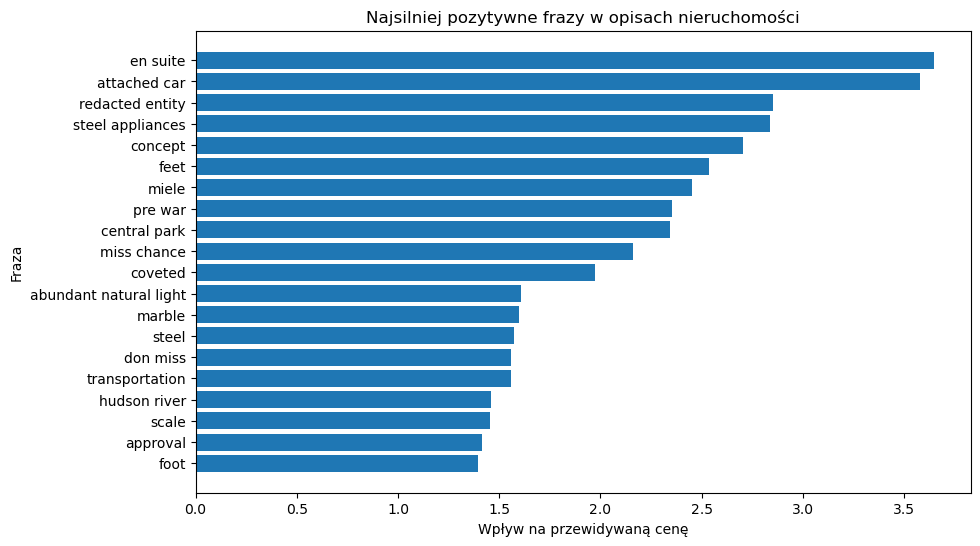

In [35]:
# ============================================================
# Wykres najważniejszych pozytywnych fraz
# ============================================================

import matplotlib.pyplot as plt

top_positive = positive_phrases.sort_values(
    by="coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive["feature"],
    top_positive["coefficient"]
)

plt.xlabel("Wpływ na przewidywaną cenę")
plt.ylabel("Fraza")

plt.title(
    "Najsilniej pozytywne frazy w opisach nieruchomości"
)

plt.show()

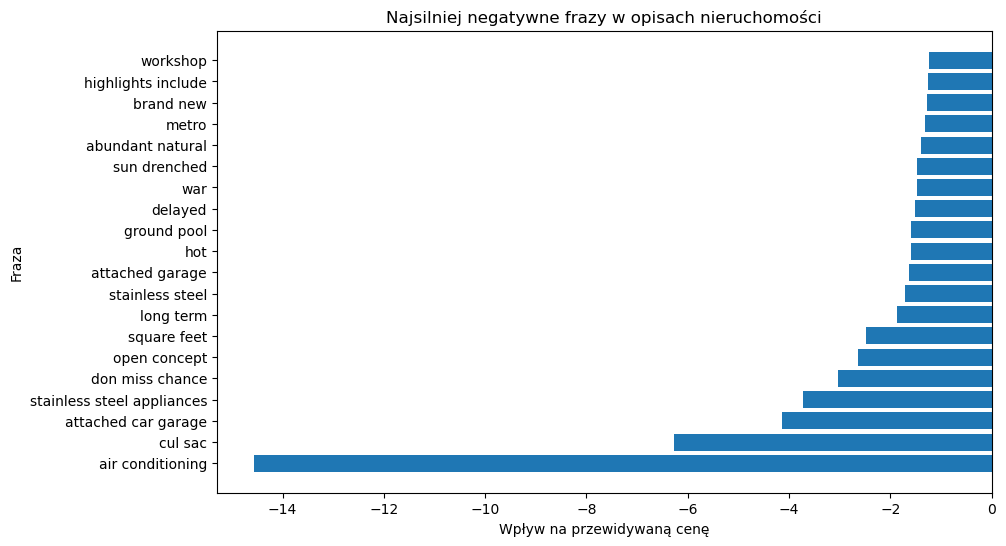

In [36]:
# ============================================================
# Wykres najważniejszych negatywnych fraz
# ============================================================

top_negative = negative_phrases.sort_values(
    by="coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative["feature"],
    top_negative["coefficient"]
)

plt.xlabel("Wpływ na przewidywaną cenę")
plt.ylabel("Fraza")

plt.title(
    "Najsilniej negatywne frazy w opisach nieruchomości"
)

plt.show()